# Week 3 — Regression Perspective on Portfolio Theory

This notebook connects **regression** to **portfolio construction** and shows how
**ridge shrinkage** stabilizes Markowitz-style weights.

**Roadmap**

1. Load returns (Week 2 universe).
2. Britten–Jones: portfolio weights *are* OLS coefficients (tangency $\propto \Sigma^{-1}\mu$).
3. Ridge coefficient paths + a scikit-learn cross-check.
4. The bridge: ridge coefficients $\leftrightarrow$ diagonal-loaded (stabilized) weights.
5. Rolling-window stability: OLS vs ridge turnover.
6. Bias–variance takeaway.

Math derivations live in `personal/math/week3/Week3-Math-Note.pdf` (local, gitignored); the implementation is in
`portfolio/ridge_regression.py` (Step 3).

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

# Make the `portfolio` package importable when running from Code/notebooks/.
sys.path.insert(0, os.path.abspath(".."))
import portfolio as pf

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
RNG = np.random.default_rng(42)

print("portfolio loaded:", hasattr(pf, "ridge_portfolio_weights"))

portfolio loaded: True


## 1. Load returns

We reuse the Week 2 universe (`AAPL, MSFT, GOOGL, JPM, XOM`, 2019→present) via
`portfolio.data`. If the download is unavailable, we fall back to a reproducible
two-factor synthetic model so the notebook always runs offline.

In [2]:
TICKERS = ["AAPL", "MSFT", "GOOGL", "JPM", "XOM"]
START = "2019-01-01"


def load_returns():
    """Try real Yahoo data; fall back to a synthetic 2-factor model offline."""
    try:
        prices = pf.download_prices(TICKERS, start=START)
        rets = pf.prices_to_returns(prices)
        if rets.shape[0] > 250:
            span = f"{rets.index.min().date()} to {rets.index.max().date()}"
            print(f"Real data: {rets.shape[0]} days x {rets.shape[1]} assets ({span})")
            return rets, True
        print("Too few rows downloaded; using synthetic fallback.")
    except Exception as exc:  # offline / API change / empty frame
        print(f"Download failed ({type(exc).__name__}); using synthetic fallback.")

    T = 1500
    factors = RNG.standard_normal((T, 2)) * 0.01
    loadings = np.array([[1.1, 0.2], [1.0, 0.3], [1.2, 0.1], [0.6, 0.9], [0.4, -0.6]])
    idio = RNG.standard_normal((T, len(TICKERS))) * 0.008
    drift = np.array([0.0006, 0.0006, 0.0007, 0.0004, 0.0003])
    R = factors @ loadings.T + idio + drift
    idx = pd.bdate_range("2019-01-02", periods=T)
    return pd.DataFrame(R, columns=TICKERS, index=idx), False


returns, is_real = load_returns()
returns.head()

Real data: 1872 days x 5 assets (2019-01-03 to 2026-06-15)


Ticker,AAPL,GOOGL,JPM,MSFT,XOM
2019-01-03,-0.099607,-0.027696,-0.014212,-0.036788,-0.015354
2019-01-04,0.042689,0.051294,0.036866,0.046510,0.036870
2019-01-07,-0.002226,-0.001994,0.000695,0.001275,0.005200
2019-01-08,0.019063,0.008783,-0.001886,0.007250,0.007271
2019-01-09,0.016982,-0.003427,-0.001690,0.014300,0.005275


## 2. Britten–Jones: portfolio weights *are* OLS coefficients

Regress a vector of ones on the excess returns with **no intercept**:

$$\mathbf{1}_T = R\,\boldsymbol{\theta} + \boldsymbol{\varepsilon}, \qquad
\hat{\boldsymbol{\theta}} = (R^\top R)^{-1} R^\top \mathbf{1}_T \;\propto\; \hat\Sigma^{-1}\boldsymbol{\mu}.$$

Normalizing $\hat{\boldsymbol{\theta}}$ to sum to one gives the tangency weights. Below we
confirm `britten_jones_weights` reproduces the closed-form $\hat\Sigma^{-1}\boldsymbol{\mu}$ direction.

In [3]:
w_bj = pf.britten_jones_weights(returns)

# Independent check: closed-form tangency direction from the uncentered moments.
R = returns.to_numpy()
T = R.shape[0]
Su = R.T @ R / T          # uncentered second moment (proportional to R^T R)
mu = R.mean(axis=0)       # mean excess returns
tan = np.linalg.solve(Su, mu)
w_closed = pd.Series(tan / tan.sum(), index=returns.columns)

compare = pd.DataFrame({"britten_jones": w_bj, "closed_form": w_closed})
print("max |britten_jones - closed_form| =", float((w_bj - w_closed).abs().max()))
print("weights sum to:", round(float(w_bj.sum()), 6))
compare

max |britten_jones - closed_form| = 2.3314683517128287e-15
weights sum to: 1.0


,britten_jones,closed_form
Ticker,,
AAPL,0.431552,0.431552
GOOGL,0.347666,0.347666
JPM,0.147680,0.147680
MSFT,-0.070128,-0.070128
XOM,0.143229,0.143229


## 3. Ridge coefficient paths

Ridge replaces $(R^\top R)$ with $(R^\top R + \lambda I)$. As $\lambda$ grows, every
coefficient is pulled toward zero (the noisy, small-eigenvalue directions fastest).
We sweep a log-spaced grid of penalties and plot each asset's coefficient.

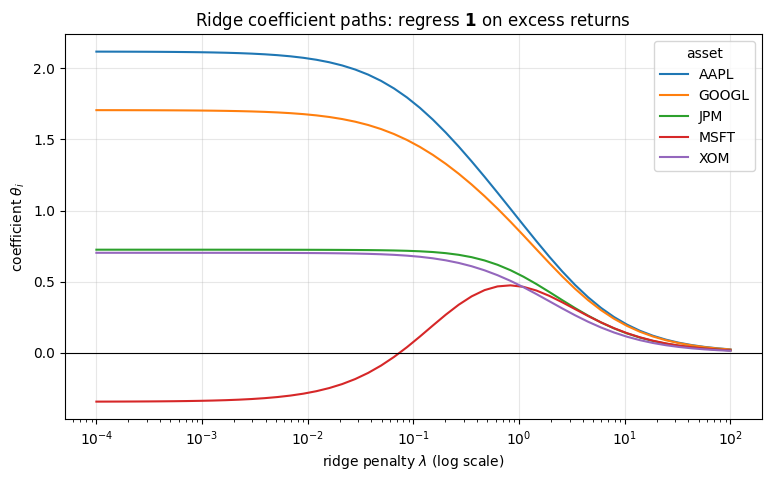

||theta|| shrinks from 2.920 (lambda=1.0e-04) to 0.043 (lambda=100)


In [4]:
ones = np.ones(T)
lambdas = np.logspace(-4, 2, 50)        # penalty grid (relative to R^T R ~ T*Sigma)
paths = pf.ridge_path(R, ones, lambdas)  # shape (len(lambdas), n_assets)

fig, ax = plt.subplots()
for j, name in enumerate(returns.columns):
    ax.plot(lambdas, paths[:, j], label=name)
ax.set_xscale("log")
ax.set_xlabel(r"ridge penalty $\lambda$ (log scale)")
ax.set_ylabel(r"coefficient $\theta_i$")
ax.set_title(r"Ridge coefficient paths: regress $\mathbf{1}$ on excess returns")
ax.axhline(0.0, color="black", linewidth=0.8)
ax.legend(title="asset")
plt.show()

coef_norm = np.linalg.norm(paths, axis=1)
print(f"||theta|| shrinks from {coef_norm[0]:.3f} (lambda={lambdas[0]:.1e}) "
      f"to {coef_norm[-1]:.3f} (lambda={lambdas[-1]:.0f})")

**Cross-check with scikit-learn.** Our pure-NumPy `ridge_coefficients` should match
`sklearn.linear_model.Ridge(alpha=λ, fit_intercept=False)` to numerical precision.

In [5]:
try:
    from sklearn.linear_model import Ridge

    rows = []
    for lam in [0.1, 1.0, 10.0]:
        skl = Ridge(alpha=lam, fit_intercept=False).fit(R, ones).coef_
        ours = pf.ridge_coefficients(R, ones, lam)
        rows.append({"lambda": lam, "max_abs_diff": float(np.max(np.abs(skl - ours)))})
    print(pd.DataFrame(rows).to_string(index=False))
    print("-> pure-NumPy ridge matches scikit-learn.")
except ImportError:
    print("scikit-learn not installed; skipping cross-check (pip install scikit-learn).")

 lambda  max_abs_diff
    0.1  7.216450e-16
    1.0  2.220446e-16
   10.0  5.551115e-17
-> pure-NumPy ridge matches scikit-learn.


## 4. The bridge: ridge coefficients $\leftrightarrow$ stabilized weights

Normalizing the ridge coefficients to a budget gives ridge-stabilized portfolio
weights, equivalent to diagonal loading $(\hat\Sigma + \tfrac{\lambda}{T} I)^{-1}\boldsymbol{\mu}$.
Plotting both side by side shows the same $\lambda$ knob acting on coefficients (left)
and on portfolio weights (right).

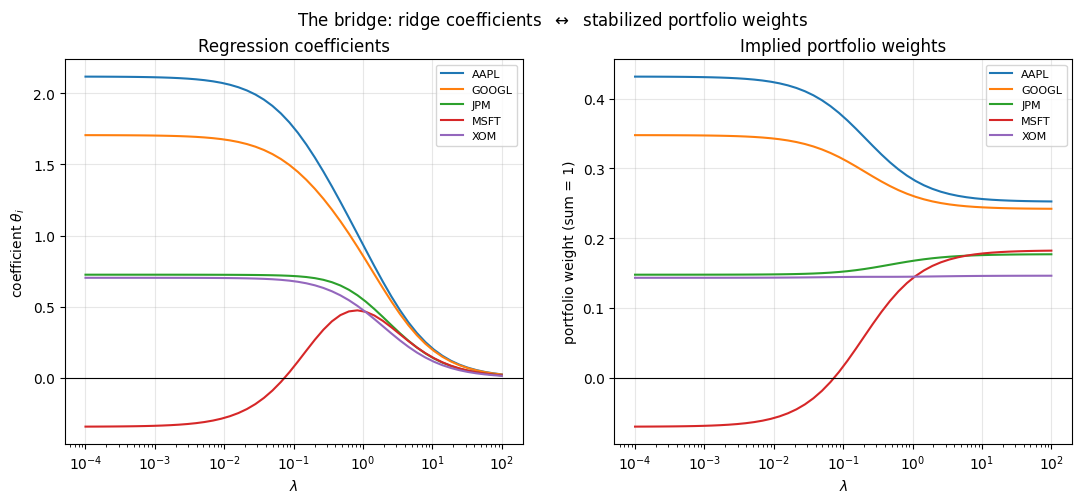

In [6]:
w_paths = np.vstack([
    pf.ridge_portfolio_weights(returns, float(lam)).to_numpy() for lam in lambdas
])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
for j, name in enumerate(returns.columns):
    ax1.plot(lambdas, paths[:, j], label=name)
ax1.set_xscale("log")
ax1.set_xlabel(r"$\lambda$")
ax1.set_ylabel(r"coefficient $\theta_i$")
ax1.set_title("Regression coefficients")
ax1.axhline(0.0, color="black", linewidth=0.8)
ax1.legend(fontsize=8)

for j, name in enumerate(returns.columns):
    ax2.plot(lambdas, w_paths[:, j], label=name)
ax2.set_xscale("log")
ax2.set_xlabel(r"$\lambda$")
ax2.set_ylabel("portfolio weight (sum = 1)")
ax2.set_title("Implied portfolio weights")
ax2.axhline(0.0, color="black", linewidth=0.8)
ax2.legend(fontsize=8)

fig.suptitle(r"The bridge: ridge coefficients  $\leftrightarrow$  stabilized portfolio weights")
plt.show()

## 5. Rolling-window stability: the shrinkage payoff

The practical payoff of shrinkage is **out-of-sample stability**. Tangency weights are a
poor vehicle for this test: they also depend on noisy *mean* estimates and on dividing by
the coefficient sum, so their turnover is erratic (try it — it is huge and non-monotonic).

To isolate the *covariance-inversion* instability that ridge actually fixes, we use the
global minimum-variance (GMV) portfolio, whose signal is the ones vector:

$$w_{\text{GMV}} \propto \Sigma^{-1}\mathbf{1}, \qquad
w_{\text{ridge}} \propto (\Sigma + \lambda I)^{-1}\mathbf{1}.$$

Diagonal loading $\Sigma + \lambda I$ is the same ridge move (now applied to the ones
problem); as $\lambda$ grows the weights move toward equal weight. We re-estimate on a
rolling window and measure L1 turnover with `portfolio.weight_turnover`.

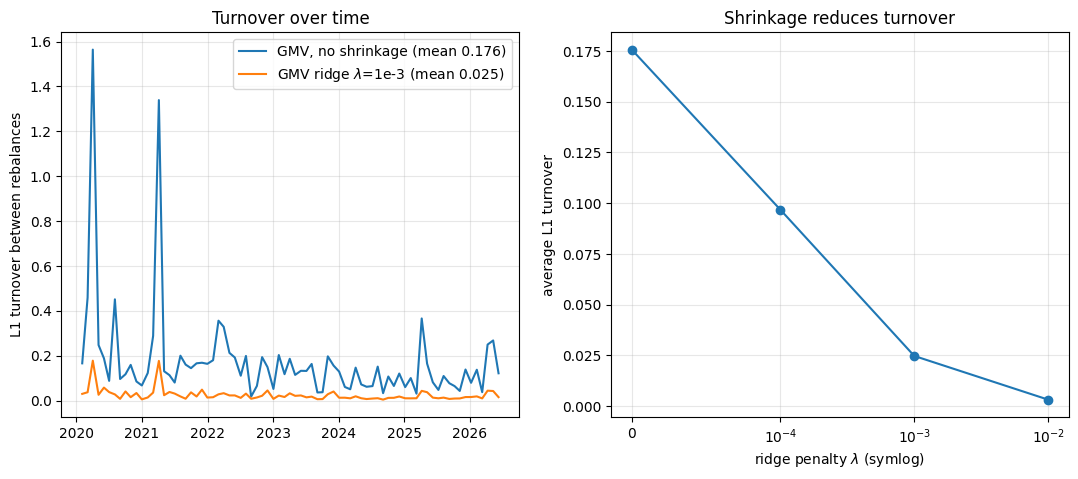

Average turnover by lambda:
  lambda=0.0    : 0.176
  lambda=0.0001 : 0.097
  lambda=0.001  : 0.025
  lambda=0.01   : 0.003


In [7]:
def gmv_ridge_weights(returns_window, lam):
    """Diagonal-loaded GMV weights: (Sigma + lam*I)^{-1} 1, normalized to sum to one."""
    cov = returns_window.cov().to_numpy()
    n = cov.shape[0]
    w = np.linalg.solve(cov + lam * np.eye(n), np.ones(n))
    return pd.Series(w / w.sum(), index=returns_window.columns)


def rolling_weights(returns, weight_fn, window=252, step=21):
    """Re-estimate weights every `step` rows on a trailing `window`."""
    dates, rows = [], []
    for end in range(window, len(returns) + 1, step):
        rows.append(weight_fn(returns.iloc[end - window:end]))
        dates.append(returns.index[end - 1])
    return pd.DataFrame(rows, index=dates)


lam_grid = [0.0, 1e-4, 1e-3, 1e-2]   # 0 = plain GMV; covariance entries are O(1e-4)
W_by_lam = {lam: rolling_weights(returns, lambda r, l=lam: gmv_ridge_weights(r, l))
            for lam in lam_grid}
turnover_by_lam = {lam: pf.weight_turnover(W).mean() for lam, W in W_by_lam.items()}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

to_plain = pf.weight_turnover(W_by_lam[0.0])
to_ridge = pf.weight_turnover(W_by_lam[1e-3])
ax1.plot(to_plain.index, to_plain.values, label=f"GMV, no shrinkage (mean {to_plain.mean():.3f})")
ax1.plot(to_ridge.index, to_ridge.values, label=fr"GMV ridge $\lambda$=1e-3 (mean {to_ridge.mean():.3f})")
ax1.set_ylabel("L1 turnover between rebalances")
ax1.set_title("Turnover over time")
ax1.legend()

ax2.plot(list(turnover_by_lam), list(turnover_by_lam.values()), marker="o")
ax2.set_xscale("symlog", linthresh=1e-4)
ax2.set_xlabel(r"ridge penalty $\lambda$ (symlog)")
ax2.set_ylabel("average L1 turnover")
ax2.set_title("Shrinkage reduces turnover")
plt.show()

print("Average turnover by lambda:")
for lam, t in turnover_by_lam.items():
    print(f"  lambda={lam:<7}: {t:.3f}")

## 6. Bias–variance takeaway

- **OLS / Britten–Jones** is unbiased but high-variance: it inverts $\hat\Sigma$, so noisy
  small eigenvalues produce extreme, unstable long/short weights.
- **Ridge** adds a little bias (shrinks $\|\boldsymbol{\theta}\|$) to cut variance a lot,
  lowering the condition number of the inverted matrix. On the GMV experiment above this
  collapsed average turnover by orders of magnitude as $\lambda$ grew.
- The penalty $\lambda$ is the bias–variance dial; pick it by cross-validation or
  out-of-sample variance (Week 7–8).

**Next steps:** Step 5 formalizes these experiments and saves the figures to
`Code/figures/week3_*.png`; Step 6 writes the standalone bias–variance note. Full
derivations: `personal/math/week3/Week3-Math-Note.pdf` (local, gitignored).